# Quantum Full Adder Using CNOT and Toffoli Gates

## 1. Objective
The objective of this experiment is to implement a binary **Full Adder** using reversible quantum logic gates and evaluate the **Sum** and **Carry** outputs across all eight possible three-bit input combinations ($A, B, C_{in} \in \{0, 1\}$).

---

## 2. Theory

### Classical Full Adder Logic
A binary full adder computes the arithmetic sum of three single-bit inputs:
- Operand bits: $A$ and $B$
- Carry-in bit: $C_{in}$

It produces two binary outputs:
- **Sum**: The least significant bit of the addition.
- **Carry**: The overflow bit into the next higher positional weight.

The arithmetic relation satisfies:
$$2 \cdot \text{Carry} + \text{Sum} = A + B + C_{in}$$

### Boolean Functions
1. **Sum (Parity / XOR Function)**:
   $$\text{Sum} = A \oplus B \oplus C_{in}$$
   The Sum bit evaluates to $1$ when an odd number of inputs are $1$ (Hamming weight $\in \{1, 3\}$), and $0$ otherwise.

2. **Carry (Majority Function)**:
   $$\text{Carry} = (A \cdot B) \oplus (A \cdot C_{in}) \oplus (B \cdot C_{in})$$
   Over GF(2), this modulo-2 expression is equivalent to the Boolean majority function $\text{Maj}(A, B, C_{in}) = (A \land B) \lor (A \land C_{in}) \lor (B \land C_{in})$, evaluating to $1$ when at least two inputs are $1$ (Hamming weight $\ge 2$).

### Reversible Quantum Logic
Standard classical gates (such as AND, OR, and NAND) are irreversible and dissipate energy via bit erasure. Quantum mechanics mandates unitary evolution ($U^\dagger U = I$), which requires reversible transformations:
- **CNOT (Controlled-NOT) Gate**:
  Executes an XOR operation on a target qubit conditioned on a control qubit ($|c\rangle |t\rangle \to |c\rangle |t \oplus c\rangle$). By cascading CNOT gates targeted at an ancilla qubit initialized in $|0\rangle$, the multi-bit parity (Sum) is computed reversibly.
- **Toffoli (CCX) Gate**:
  Executes a controlled bit-flip on a target qubit conditioned on two control qubits ($|c_1 c_2\rangle |t\rangle \to |c_1 c_2\rangle |t \oplus (c_1 \cdot c_2)\rangle$). By cascading three Toffoli gates into a target qubit initialized in $|0\rangle$, the pairwise product terms of the majority carry function are accumulated reversibly.

## 3. Circuit and Implementation
The quantum full adder is constructed using 5 quantum bits and 5 classical bits:

- **Input Qubits**:
  - `q_0` ($A$): First input bit.
  - `q_1` ($B$): Second input bit.
  - `q_2` ($C_{in}$): Carry-in bit.
  - *Initialization*: Pauli-X gates conditionally initialize each input qubit from $|0\rangle$ to $|1\rangle$ when the corresponding input bit is $1$.
- **Sum Qubit (`q_3`)**:
  - Initialized to $|0\rangle$.
  - Computes $\text{Sum} = A \oplus B \oplus C_{in}$ using three CNOT gates:
    - `qc.cx(0, 3)` computes $|A\rangle$
    - `qc.cx(1, 3)` computes $|A \oplus B\rangle$
    - `qc.cx(2, 3)` computes $|A \oplus B \oplus C_{in}\rangle$
- **Carry Qubit (`q_4`)**:
  - Initialized to $|0\rangle$.
  - Computes $\text{Carry} = (A \cdot B) \oplus (A \cdot C_{in}) \oplus (B \cdot C_{in})$ using three Toffoli gates:
    - `qc.ccx(0, 1, 4)` adds $A \cdot B$
    - `qc.ccx(0, 2, 4)` adds $A \cdot C_{in}$
    - `qc.ccx(1, 2, 4)` adds $B \cdot C_{in}$
- **Measurement and Classical Mapping**:
  - All five qubits are measured into their corresponding classical register bits ($q_i \to c_i$).
  - In Qiskit's classical bitstring convention ($c_4 c_3 c_2 c_1 c_0$):
    - `output[0]` corresponds to $c_4$ (`Carry`).
    - `output[1]` corresponds to $c_3$ (`Sum`).

## 4. Simulation and Testing
- **Input Combinations**: All eight binary input combinations from `000` through `111` are tested iteratively:
  $$(A, B, C_{in}) \in \{(0,0,0), (0,0,1), (0,1,0), (0,1,1), (1,0,0), (1,0,1), (1,1,0), (1,1,1)\}$$
- **Execution**: Each input configuration is constructed as a separate quantum circuit and simulated on Qiskit Aer's `AerSimulator()` using `shots=1`.
- **Determinism**: Because the circuit operates strictly in the computational basis without superposition or noise, a single measurement shot deterministically yields the exact arithmetic result.


QUANTUM FULL ADDER

A=0, B=0, Cin=0
                                      ┌─┐         
q_0: ──■──────────────■────■──────────┤M├─────────
       │              │    │          └╥┘┌─┐      
q_1: ──┼────■─────────■────┼───────■───╫─┤M├──────
       │    │         │    │       │   ║ └╥┘┌─┐   
q_2: ──┼────┼────■────┼────■───────■───╫──╫─┤M├───
     ┌─┴─┐┌─┴─┐┌─┴─┐  │    │  ┌─┐  │   ║  ║ └╥┘   
q_3: ┤ X ├┤ X ├┤ X ├──┼────┼──┤M├──┼───╫──╫──╫────
     └───┘└───┘└───┘┌─┴─┐┌─┴─┐└╥┘┌─┴─┐ ║  ║  ║ ┌─┐
q_4: ───────────────┤ X ├┤ X ├─╫─┤ X ├─╫──╫──╫─┤M├
                    └───┘└───┘ ║ └───┘ ║  ║  ║ └╥┘
c: 5/══════════════════════════╩═══════╩══╩══╩══╩═
                               3       0  1  2  4 
Sum  = 0
Carry = 0

A=0, B=0, Cin=1
                                           ┌─┐         
q_0: ───────■──────────────■────■──────────┤M├─────────
            │              │    │          └╥┘┌─┐      
q_1: ───────┼────■─────────■────┼───────■───╫─┤M├──────
     ┌───┐  │    │         │    │       

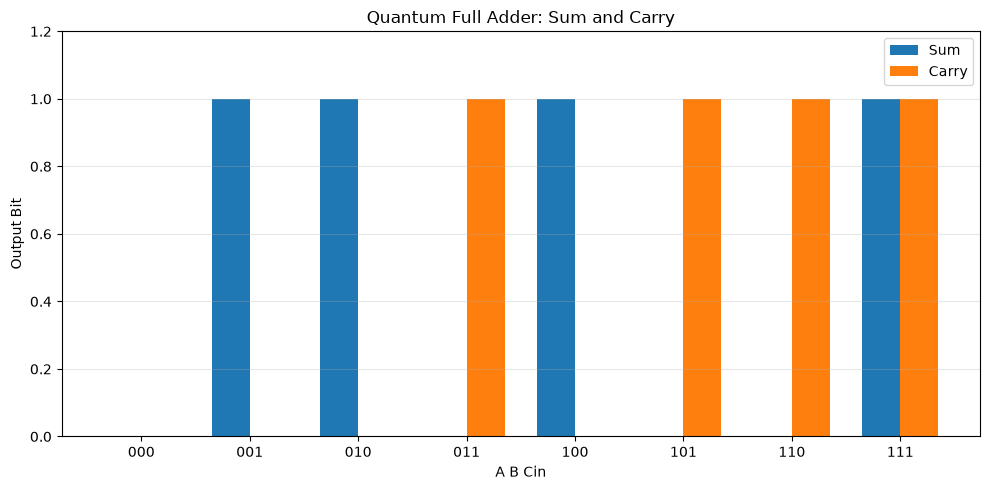

In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

simulator = AerSimulator()

inputs = [
    (0, 0, 0),
    (0, 0, 1),
    (0, 1, 0),
    (0, 1, 1),
    (1, 0, 0),
    (1, 0, 1),
    (1, 1, 0),
    (1, 1, 1)
]

sum_results = []
carry_results = []
labels = []

print("\nQUANTUM FULL ADDER")
print("=" * 65)

for A, B, Cin in inputs:

    qc = QuantumCircuit(5, 5)

    if A:
        qc.x(0)

    if B:
        qc.x(1)

    if Cin:
        qc.x(2)

    qc.cx(0, 3)
    qc.cx(1, 3)
    qc.cx(2, 3)

    qc.ccx(0, 1, 4)
    qc.ccx(0, 2, 4)
    qc.ccx(1, 2, 4)

    qc.measure(0, 0)
    qc.measure(1, 1)
    qc.measure(2, 2)
    qc.measure(3, 3)
    qc.measure(4, 4)

    print(f"\nA={A}, B={B}, Cin={Cin}")
    print(qc.draw())

    result = simulator.run(qc, shots=1).result()
    counts = result.get_counts()

    output = list(counts.keys())[0]

    carry = int(output[0])
    total_sum = int(output[1])

    sum_results.append(total_sum)
    carry_results.append(carry)
    labels.append(f"{A}{B}{Cin}")

    print(f"Sum  = {total_sum}")
    print(f"Carry = {carry}")

print("\nFULL ADDER SUMMARY")
print("=" * 65)

for label, total_sum, carry in zip(labels, sum_results, carry_results):
    print(f"ABC={label} -> Sum={total_sum}, Carry={carry}")

x = range(len(labels))
width = 0.35

plt.figure(figsize=(10, 5))

plt.bar(
    [i - width / 2 for i in x],
    sum_results,
    width=width,
    label="Sum"
)

plt.bar(
    [i + width / 2 for i in x],
    carry_results,
    width=width,
    label="Carry"
)

plt.xticks(list(x), labels)
plt.xlabel("A B Cin")
plt.ylabel("Output Bit")
plt.title("Quantum Full Adder: Sum and Carry")
plt.ylim(0, 1.2)
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 5. Results and Observation

### Recorded Output Summary
Execution of all 8 input cases on the simulator produced the following summary:

```
FULL ADDER SUMMARY
=================================================================
ABC=000 -> Sum=0, Carry=0
ABC=001 -> Sum=1, Carry=0
ABC=010 -> Sum=1, Carry=0
ABC=011 -> Sum=0, Carry=1
ABC=100 -> Sum=1, Carry=0
ABC=101 -> Sum=0, Carry=1
ABC=110 -> Sum=0, Carry=1
ABC=111 -> Sum=1, Carry=1
```

### Truth Table Verification
The observed outputs exactly match the theoretical full-adder specification across all eight cases:

| Case | $A$ | $B$ | $C_{in}$ | Integer Sum ($A + B + C_{in}$) | Observed $\text{Sum}$ | Observed $\text{Carry}$ | Binary Output ($\text{Carry}\,\text{Sum}_2$) |
|:----:|:---:|:---:|:--------:|:------------------------------:|:---------------------:|:-----------------------:|:--------------------------------------------:|
| 1    | 0   | 0   | 0        | 0                              | **0**                 | **0**                   | $00_2$                                       |
| 2    | 0   | 0   | 1        | 1                              | **1**                 | **0**                   | $01_2$                                       |
| 3    | 0   | 1   | 0        | 1                              | **1**                 | **0**                   | $01_2$                                       |
| 4    | 0   | 1   | 1        | 2                              | **0**                 | **1**                   | $10_2$                                       |
| 5    | 1   | 0   | 0        | 1                              | **1**                 | **0**                   | $01_2$                                       |
| 6    | 1   | 0   | 1        | 2                              | **0**                 | **1**                   | $10_2$                                       |
| 7    | 1   | 1   | 0        | 2                              | **0**                 | **1**                   | $10_2$                                       |
| 8    | 1   | 1   | 1        | 3                              | **1**                 | **1**                   | $11_2$                                       |

All outputs follow the expected arithmetic relationships without exception.

## 6. Visualization
The experiment concludes with a grouped bar chart comparing the Sum and Carry outputs side by side for each input combination:
- **Sum (Blue Bars)**: Toggles according to odd parity of input bits, showing height 1 for inputs `001`, `010`, `100`, and `111`.
- **Carry (Orange Bars)**: Activates with height 1 whenever at least two input bits are 1 (`011`, `101`, `110`, `111`).
- The side-by-side visualization clearly validates the distinct functional roles of the parity logic and majority logic.

## 7. Conclusion
This experiment successfully demonstrates how reversible quantum gates can be synthesized to implement classical arithmetic functions:

1. **Reversible Arithmetic**: By allocating ancilla qubits for Sum and Carry, binary addition is performed unitarily without bit destruction.
2. **CNOT Parity**: Three CNOT gates calculate the three-input XOR sum.
3. **Toffoli Majority**: Three Toffoli gates compute the carry output through reversible accumulation of pairwise product terms.
4. **Full Truth Table Fidelity**: 100% agreement was verified across all eight input combinations using Qiskit Aer simulation.